## Clustering

In [7]:
from sklearn.cluster import DBSCAN
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt
import torch

embeddings_data = np.load('Data/spaformer_embeddings.npy')

In [8]:
print(embeddings_data[2])

[ 1.89270556e-01  7.13645339e-01 -1.11516364e-01 -1.52264565e-01
 -1.63026586e-01 -1.22918367e-01 -1.35511085e-01  1.41504988e-01
 -1.66060746e-01 -6.13029823e-02 -1.69654429e-01  1.33984700e-01
 -1.60663486e-01 -1.00289024e-01 -1.57660201e-01 -1.61561191e-01
  1.95102870e+00 -1.66873951e-02  2.21981004e-01 -1.69527322e-01
 -1.69611320e-01  3.19050193e-01  2.98317164e-01  1.80977270e-01
  2.07481250e-01  1.90376985e+00  4.64879721e-01  2.62467170e+00
  6.71113908e-01  6.83755577e-01  1.91173524e-01 -1.64288178e-01
  7.92589545e-01 -6.38104528e-02 -1.39165714e-01 -1.69969738e-01
 -1.62136361e-01  5.98187268e-01  8.82737100e-01  6.94906652e-01
 -1.15866460e-01 -3.79127078e-02 -1.63149357e-01  3.11591178e-01
  1.72026944e+00 -1.02065623e-01 -1.68438569e-01 -3.79543491e-02
  1.15355575e+00 -5.69811352e-02  9.93029237e-01  1.45571232e+00
 -2.37133186e-02  1.04647708e+00  8.23139623e-02 -1.29355162e-01
 -1.34826973e-01 -3.08653768e-02  7.14143505e-03 -1.29473478e-01
 -4.13411409e-02  2.73177

In [9]:
# clustering = DBSCAN(eps=0.5, min_samples=5).fit(embeddings_data)
clustering = DBSCAN(eps=0.8, min_samples=3).fit(embeddings_data)

labels = clustering.labels_
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

print(f"Silhouette Coefficient: {metrics.silhouette_score(embeddings_data, labels):.3f}")

Estimated number of clusters: 73
Estimated number of noise points: 1314
Silhouette Coefficient: -0.241


In [10]:
clustering.n_features_in_
clustering.labels_

array([-1,  0, -1, ...,  0,  1,  0], shape=(4992,))

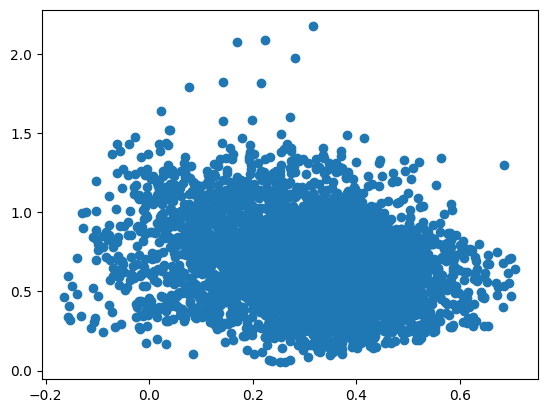

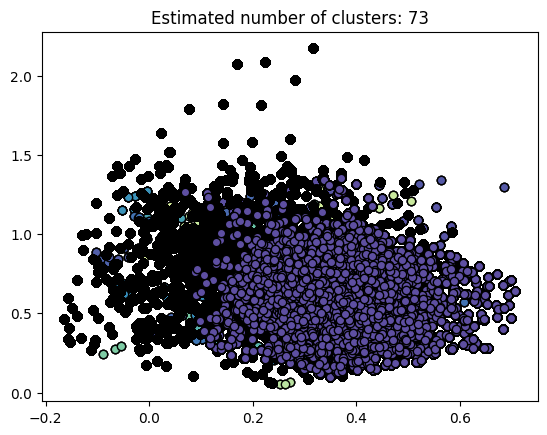

In [11]:
plt.scatter(embeddings_data[:, 0], embeddings_data[:, 1])
plt.show()

core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[clustering.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(labels))]
for k, col in zip(labels, colors):
	if k == -1:
		# Black used for noise.
		col = [0, 0, 0, 1]

	class_member_mask = labels == k
    
	# Plot noise
	xy = embeddings_data[class_member_mask & ~core_samples_mask]
	plt.plot(
		xy[:, 0],
		xy[:, 1],
		"o",
		markerfacecolor=tuple(col),
		markeredgecolor="k",
		markersize=6,
	)
    
	# Plot cluster items
	xy = embeddings_data[class_member_mask & core_samples_mask]
	plt.plot(
		xy[:, 0],
		xy[:, 1],
		"o",
		markerfacecolor=tuple(col),
		markeredgecolor="k",
		markersize=6,
	)
    

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

## Hypergraph Construction

In [ ]:
dict_hypergraph = dict()

for hyperedge, (node_i, node) in zip(clustering.labels_, enumerate(embeddings_data)):
	hyperedge_i = hyperedge + 1
	if hyperedge_i not in dict_hypergraph:
		dict_hypergraph[hyperedge_i] = [node_i]
	else:
		dict_hypergraph[hyperedge_i].append(node_i)

dict_hypergraph[np.int64(len(dict_hypergraph.keys()))] = dict_hypergraph[0]
dict_hypergraph.pop(0)

12


In [ ]:
# data_tensor = torch.tensor(embeddings_data)
hyperedge_index = torch.tensor([
    [_v for v in dict_hypergraph.values() for _v in v],
    [k for k, v in dict_hypergraph.items() for _ in v],
])

print(hyperedge_index)

tensor([[   1,    3,    4,  ..., 4978, 4984, 4985],
        [   1,    1,    1,  ...,   74,   74,   74]])


In [15]:
# from torch_geometric.nn import HypergraphConv

# test = HypergraphConv(len(embeddings_data), len(clustering.labels_))
# test(embeddings_data, hyperedge_index)

In [16]:
# from torch.utils.data import Dataset

# class EmbeddingDataset(Dataset):
# 	def __init__(self, data):
# 		self.data = data

# 	def __len__(self):
# 		return len(self.data)

# 	def __getitem__(self, index):
# 		return self.data[index]

In [17]:
# import torch.nn.functional as F
# from torch_geometric.nn import GCNConv

# class CNN(torch.nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.conv1 = GCNConv(len(clustering.labels_), 16)

#     def forward(self, data):
#         x, edge_index = data.x, data.edge_index

#         x = self.conv1(x, edge_index)
#         x = F.relu(x)
#         x = F.dropout(x, training=self.training)
#         x = self.conv2(x, edge_index)

#         return F.log_softmax(x, dim=1)

In [18]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model = GCN().to(device)
# data = dataset[0].to(device)
# optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# model.train()
# for epoch in range(200):
#     optimizer.zero_grad()
#     out = model(data)
#     loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
#     loss.backward()
#     optimizer.step()

## Grid Search (Ignore)

In [19]:
# highest_sil_coef = -1.0
# least_noise = 3000

# for i_eps in np.linspace(0, 1, 100, endpoint=False):
# 	if i_eps <= 0:
# 		continue

# 	for j_min_samples in range(1, 25):
# 		# print(i_eps, j_min_samples)
# 		try:
# 			cluster = DBSCAN(eps=i_eps, min_samples=j_min_samples).fit(data)
# 			labels = cluster.labels_
# 			sil_coef = metrics.silhouette_score(data, labels)
# 			cluster_count = len(set(labels)) - (1 if -1 in labels else 0)
# 			noise_count = list(labels).count(-1)

# 			# if highest_sil_coef < sil_coef and 3 < cluster_count < 100 and noise_count <= least_noise:
# 			# if highest_sil_coef < sil_coef and 3 < cluster_count and noise_count <= least_noise:
# 			if highest_sil_coef < sil_coef and 3 < cluster_count:
# 				highest_sil_coef = sil_coef
# 				least_noise = noise_count
# 				best_cluster = cluster

# 		except:
# 			continue

# print(highest_sil_coef)

In [20]:
# print(best_cluster)
# labels = best_cluster.labels_

# n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
# n_noise_ = list(labels).count(-1)

# print("Estimated number of clusters: %d" % n_clusters_)
# print("Estimated number of noise points: %d" % n_noise_)

# print(f"Silhouette Coefficient: {metrics.silhouette_score(data, labels):.3f}")

In [21]:
# plt.scatter(data[:, 0], data[:, 1])
# plt.show()

# unique_labels = set(labels)
# core_samples_mask = np.zeros_like(labels, dtype=bool)
# core_samples_mask[best_cluster.core_sample_indices_] = True

# colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
# for k, col in zip(unique_labels, colors):
# 	if k == -1:
# 		# Black used for noise.
# 		col = [0, 0, 0, 1]

# 	class_member_mask = labels == k
    
# 	# Plot noise
# 	xy = data[class_member_mask & ~core_samples_mask]
# 	plt.plot(
# 		xy[:, 0],
# 		xy[:, 1],
# 		"o",
# 		markerfacecolor=tuple(col),
# 		markeredgecolor="k",
# 		markersize=6,
# 	)
    
# 	# Plot cluster items
# 	xy = data[class_member_mask & core_samples_mask]
# 	plt.plot(
# 		xy[:, 0],
# 		xy[:, 1],
# 		"o",
# 		markerfacecolor=tuple(col),
# 		markeredgecolor="k",
# 		markersize=6,
# 	)
    

# plt.title(f"Estimated number of clusters: {n_clusters_}")
# plt.show()